## Machine Temperature — Rolling MAD Baseline

Anomaly detection on the NAB `realKnownCause/machine_temperature_system_failure.csv` series using a rolling Median Absolute Deviation (MAD) score. This series records internal machine temperature and contains four labeled anomaly windows corresponding to a real system failure event.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# Point this to your local NAB repo
NAB_ROOT = Path("../NAB")  # <- change if needed

DATA_ROOT = NAB_ROOT / "data"
LABELS_PATH = NAB_ROOT / "labels" / "combined_labels.json"

assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert LABELS_PATH.exists(), f"LABELS_PATH not found: {LABELS_PATH}"

with open(LABELS_PATH, "r") as f:
    combined_labels = json.load(f)

# Pick a file to start with (good, realistic examples)
nab_rel_path = "realKnownCause/machine_temperature_system_failure.csv"

csv_path = DATA_ROOT / nab_rel_path
assert csv_path.exists(), f"CSV not found: {csv_path}"

df = pd.read_csv(csv_path, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Create labels column
anomaly_ts = set(combined_labels.get(nab_rel_path, []))
df["is_anomaly"] = df["timestamp"].astype(str).isin(anomaly_ts).astype(int)

df.head(), df["is_anomaly"].sum()

(            timestamp      value  is_anomaly
 0 2013-12-02 21:15:00  73.967322           0
 1 2013-12-02 21:20:00  74.935882           0
 2 2013-12-02 21:25:00  76.124162           0
 3 2013-12-02 21:30:00  78.140707           0
 4 2013-12-02 21:35:00  79.329836           0,
 np.int64(4))

### Train / Test Split

Split chronologically: the first 70% of timesteps form the training set, the remaining 30% the test set. No shuffling — preserving time order is critical to avoid leakage from future observations into the training window.

In [2]:
def time_split(df: pd.DataFrame, train_frac: float = 0.7) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not 0 < train_frac < 1:
        raise ValueError("train_frac must be between 0 and 1")
    split_idx = int(len(df) * train_frac)
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    return train_df, test_df

train_df, test_df = time_split(df, train_frac=0.7)

train_df.shape, test_df.shape, train_df["timestamp"].min(), test_df["timestamp"].min()

((15886, 3),
 (6809, 3),
 Timestamp('2013-12-02 21:15:00'),
 Timestamp('2014-01-27 00:05:00'))

### Rolling MAD Score

Computes a robust anomaly score at each timestep using a rolling window:

$$\text{score}(t) = \frac{|x_t - \tilde{x}_t|}{1.4826 \cdot \widetilde{|x_t - \tilde{x}_t|} + \varepsilon}$$

where $\tilde{x}_t$ is the rolling median over the past `window` steps and the denominator is the rolling MAD scaled to be comparable to a standard deviation under normality. Higher score = more anomalous.

In [3]:
def rolling_mad_score(
    df: pd.DataFrame,
    value_col: str = "seasonal_diff",
    window: int = 50,
    min_periods: int | None = None,
    eps: float = 1e-9,
) -> pd.Series:
    """
    Rolling robust z-score using median + MAD.
    Returns a score where larger values are more anomalous.
    """
    if min_periods is None:
        min_periods = max(10, window // 3)

    x = df[value_col]

    roll = x.rolling(window=window, min_periods=min_periods)
    median = roll.median()

    abs_dev = (x - median).abs()
    mad = abs_dev.rolling(window=window, min_periods=min_periods).median()

    # 1.4826 scales MAD to be comparable to std under normality
    score = abs_dev / (1.4826 * mad + eps)
    return score

### Baseline Detector

Apply `rolling_mad_score` directly to the raw `value` column with a 24-step window (one day of 30-min readings). A fixed threshold converts the continuous score into a binary prediction (`mad_pred = 1` when `mad_score > threshold`).

In [4]:
baseline_df = df.copy()

baseline_df["mad_score"] = rolling_mad_score(
    baseline_df,
    value_col="value",   # use raw value, not seasonal_diff
    window=24
)

fixed_threshold = 1.21  # start more conservatively for raw signal
baseline_df["mad_pred"] = (baseline_df["mad_score"] > fixed_threshold).astype(int)

baseline_df[["timestamp", "value", "is_anomaly", "mad_score", "mad_pred"]].head()

,timestamp,value,is_anomaly,mad_score,mad_pred
0,2013-12-02 21:15:00,73.967322,0,NaN,0
1,2013-12-02 21:20:00,74.935882,0,NaN,0
2,2013-12-02 21:25:00,76.124162,0,NaN,0
3,2013-12-02 21:30:00,78.140707,0,NaN,0
4,2013-12-02 21:35:00,79.329836,0,NaN,0


### Threshold Sweep

Thresholds are derived as percentiles of the **training** score distribution — no test labels are used. For each threshold we compute precision, recall, F1, and alert rate on the test set, then sort by F1 to find the best operating point.

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

def sweep_percentiles(train_scores, test_scores, y_true, percentiles):
    rows = []
    train_scores = np.asarray(train_scores)
    test_scores = np.asarray(test_scores)
    y_true = np.asarray(y_true)

    for p in percentiles:
        # Threshold derived ONLY from training distribution (prevents leakage)
        t = np.percentile(train_scores, p)
        y_pred = (test_scores > t).astype(int)

        rows.append({
            "percentile": p,
            "threshold": float(t),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "alerts": int(y_pred.sum()),
            "alert_rate": float(y_pred.mean()),
        })

    return pd.DataFrame(rows).sort_values("f1", ascending=False)

In [6]:
# Build train/test frames with scores already computed (mad_score, z_score, etc.)
train_scored = baseline_df.loc[train_df.index].dropna(subset=["mad_score"])
test_scored  = baseline_df.loc[test_df.index].dropna(subset=["mad_score"])

train_scores = train_scored["mad_score"].values
test_scores  = test_scored["mad_score"].values
y_true       = test_scored["is_anomaly"].astype(int).values

percentiles = np.arange(70.0, 99.9, 0.1) # you can adjust this range to zoom in on different parts of the curve
sweep_df = sweep_percentiles(train_scores, test_scores, y_true, percentiles)
sweep_df.head(10)

,percentile,threshold,precision,recall,f1,alerts,alert_rate
103,80.3,1.214041,0.000741,0.5,0.001479,1350,0.198267
102,80.2,1.211859,0.000735,0.5,0.001468,1360,0.199736
101,80.1,1.207989,0.000732,0.5,0.001461,1367,0.200764
100,80.0,1.204810,0.000729,0.5,0.001456,1372,0.201498
99,79.9,1.199749,0.000723,0.5,0.001444,1383,0.203114
98,79.8,1.196004,0.000717,0.5,0.001432,1395,0.204876
97,79.7,1.192777,0.000711,0.5,0.001420,1406,0.206491
96,79.6,1.189830,0.000707,0.5,0.001411,1415,0.207813
95,79.5,1.185926,0.000704,0.5,0.001405,1421,0.208694
94,79.4,1.182798,0.000699,0.5,0.001396,1431,0.210163


#### Sweep Results

Top rows show the threshold percentile that maximises F1 on the test set. The selected threshold is then used for all downstream evaluation and visualisation.

### Point-Level Evaluation

Compute precision, recall, F1, and average precision (area under the PR curve) against the NAB ground-truth labels on the test set. These are strict point-level metrics — a prediction must exactly match a labeled anomaly timestamp to count as a hit.

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# Align baseline outputs with test set
baseline_test = baseline_df.loc[test_df.index].dropna(subset=["mad_score"])

y_true = baseline_test["is_anomaly"].astype(int).values
y_pred = baseline_test["mad_pred"].astype(int).values
scores = baseline_test["mad_score"].values

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# PR-AUC style metric (average precision) — higher is better
ap = average_precision_score(y_true, scores) if y_true.sum() > 0 else np.nan

precision, recall, f1, ap, y_true.sum(), y_pred.sum()

(0.0007347538574577516,
 0.5,
 0.001467351430667645,
 0.000788240339759301,
 np.int64(2),
 np.int64(1361))

In [8]:
true_ts = baseline_test.loc[baseline_test["is_anomaly"] == 1, "timestamp"]
pred_ts = baseline_test.loc[baseline_test["mad_pred"] == 1, "timestamp"]

true_ts, pred_ts.head()

(16340   2014-01-28 13:55:00
 19515   2014-02-08 14:30:00
 Name: timestamp, dtype: datetime64[us],
 15902   2014-01-27 01:25:00
 15914   2014-01-27 02:25:00
 15915   2014-01-27 02:30:00
 15916   2014-01-27 02:35:00
 15919   2014-01-27 02:50:00
 Name: timestamp, dtype: datetime64[us])

In [9]:
set(true_ts.astype(str)).intersection(set(pred_ts.astype(str)))

{'2014-02-08 14:30:00'}

### Near-Hit Evaluation

Exact timestamp matching is too strict for operational use — a prediction one step before or after a labeled anomaly should count. `near_hit_evaluation` relaxes matching to a configurable time tolerance (default: ±60 min):

- A labeled anomaly is **hit** if any prediction falls within the tolerance window around it.
- Reports recall over anomaly events, matched predictions, and total alerts.

This mirrors how real alert-triage workflows work and is a better indicator of practical detector quality.

In [10]:
def near_hit_evaluation(
    df,
    pred_col,
    ts_col="timestamp",
    label_col="is_anomaly",
    tolerance="60min",
):
    """
    Computes near-hit recall within a specified time tolerance.

    Returns:
        recall (float)
        matched_true (int)
        total_true (int)
        matched_predictions (int)
        total_predictions (int)
    """
    tol = pd.Timedelta(tolerance)

    true_ts = df.loc[df[label_col] == 1, ts_col].sort_values()
    pred_ts = df.loc[df[pred_col] == 1, ts_col].sort_values()

    total_true = len(true_ts)
    total_pred = len(pred_ts)

    if total_true == 0:
        return 0.0, 0, 0, 0, total_pred

    matched_true = 0
    matched_pred_indices = set()

    for i, t in enumerate(true_ts):
        # Find predictions within tolerance
        mask = (pred_ts >= t - tol) & (pred_ts <= t + tol)
        if mask.any():
            matched_true += 1
            # Track which prediction(s) were used
            matched_pred_indices.update(pred_ts[mask].index.tolist())

    recall = matched_true / total_true
    matched_predictions = len(matched_pred_indices)

    return recall, matched_true, total_true, matched_predictions, total_pred

In [11]:
baseline_test = baseline_test.copy()
baseline_test["pred"] = baseline_test["mad_pred"]

near_hit_evaluation(baseline_test, pred_col="pred", tolerance="60min")

(1.0, 2, 2, 11, 1361)

### Score Timeline

Plot the MAD score over the test window with true anomaly timestamps marked as red crosses. Spikes in the score that coincide with red markers are correctly detected events; spikes without markers are false positives.

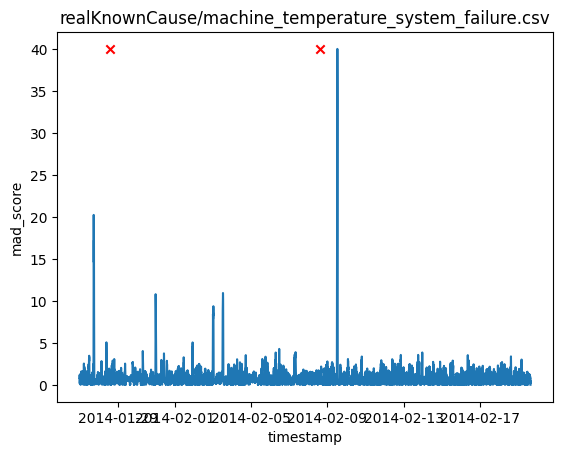

In [12]:
import matplotlib.pyplot as plt



# Max MAD score in the test set

max_score = test_scored["mad_score"].max()

# Timestamps of true anomalies in the test set

true_anomaly_ts = test_scored.loc[test_scored["is_anomaly"] == 1, "timestamp"].values



# y-coordinates for true anomalies (all at max_score)

true_anomaly_y = np.full(len(true_anomaly_ts), max_score)



plt.figure()

plt.plot(test_scored["timestamp"], test_scored["mad_score"], label="MAD score")



# mark true anomalies at the top of the plot

plt.scatter(true_anomaly_ts, true_anomaly_y, marker="x", color="red", label="true anomaly")



# plt.legend(loc="upper right")

plt.title(nab_rel_path)

plt.xlabel("timestamp")

plt.ylabel("mad_score")

plt.show()